Treinando o K-Means para diferentes valores de K...


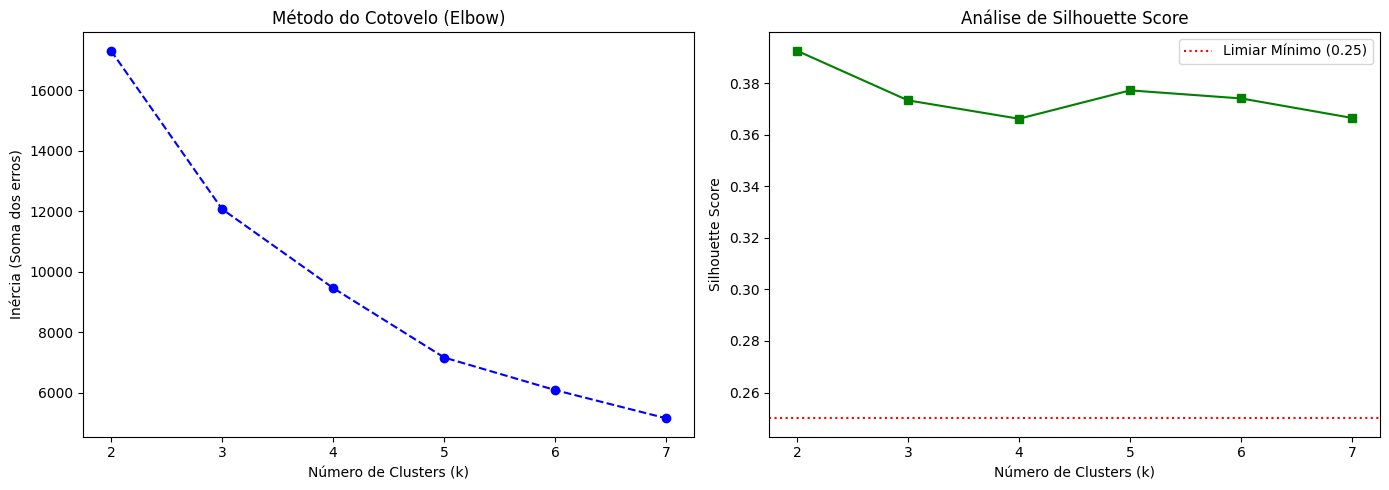


--- Teste de Estabilidade com diferentes Seeds (Para K=3) ---
Seed 0: Inércia = 12075.95
Seed 1: Inércia = 12075.95
Seed 2: Inércia = 12075.95
Seed 42: Inércia = 12076.09
Seed 100: Inércia = 12075.95


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

df = pd.read_csv("../data/base_tratada.csv")

# Selecionar APENAS as variáveis numéricas normalizadas para o K-Means
# (K-Means não lida bem com categorias)
features_kmeans = ['Valor_std', 'Valor_Log_std', 'Hora_std']
X = df[features_kmeans]

# MÉTODO DO COTOVELO E SILHOUETTE
inercia = []
silhouette_scores = []
k_range = range(2, 8) 

print("Treinando o K-Means para diferentes valores de K...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inercia.append(kmeans.inertia_)
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)

# Gráficos de Avaliação
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Cotovelo
ax1.plot(k_range, inercia, marker='o', linestyle='--', color='b')
ax1.set_title('Método do Cotovelo (Elbow)')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia (Soma dos erros)')

# Gráfico 2: Silhouette
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_title('Análise de Silhouette Score')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.axhline(y=0.25, color='r', linestyle=':', label='Limiar Mínimo (0.25)')
ax2.legend()

plt.tight_layout()
plt.show()

# --- TESTE DE ESTABILIDADE  ---
print("\n--- Teste de Estabilidade com diferentes Seeds (Para K=3) ---")
seeds = [0, 1, 2, 42, 100]
for seed in seeds:
    kmeans_test = KMeans(n_clusters=3, random_state=seed, n_init=10)
    kmeans_test.fit(X)
    print(f"Seed {seed}: Inércia = {kmeans_test.inertia_:.2f}")

In [14]:
import pandas as pd
from kmodes.kprototypes import KPrototypes

# Definir as colunas que vamos usar
# Numéricas (já normalizadas)
cols_num = ['Valor_std', 'Valor_Log_std', 'Hora_std']
# Categóricas (texto ou 0/1)
cols_cat = ['TipoChave', 'Status', 'FimDeSemana', 'Madrugada', 'Horario_Comercial']

# O K-Prototypes precisa que os dados sejam passados num formato específico (matriz)
df_kproto = df[cols_num + cols_cat].copy()

# Descobrir quais são os índices das colunas categóricas
indices_categoricos = [df_kproto.columns.get_loc(col) for col in cols_cat]

# Treinar o K-Prototypes (K=5 com base no teste do Cotovelo)
print("Treinando o K-Prototypes...")
kproto = KPrototypes(n_clusters=5, init='Cao', random_state=42, n_jobs=-1)
clusters_kproto = kproto.fit_predict(df_kproto.values, categorical=indices_categoricos)

df['Cluster_KPrototypes'] = clusters_kproto
print("Concluído! Perfis categóricos criados.")

Treinando o K-Prototypes...
Concluído! Perfis categóricos criados.


In [15]:
from sklearn_extra.cluster import KMedoids

# Apenas as numéricas, pois a matemática do PAM funciona melhor
X_num = df[cols_num]

print("A treinar o K-Medóides (PAM)...")
# Usamos K=5 novamente para manter a coerência
kmedoids = KMedoids(n_clusters=5, random_state=42, init='k-medoids++')
clusters_kmed = kmedoids.fit_predict(X_num)

df['Cluster_KMedoides'] = clusters_kmed
print("Concluído! Clusters resistentes a outliers criados.")

A treinar o K-Medóides (PAM)...
Concluído! Clusters resistentes a outliers criados.


In [16]:
from sklearn.cluster import DBSCAN

print("A treinar o DBSCAN para isolar anomalias...")

# O 'eps' é o raio de busca (distância) e 'min_samples' é o mínimo de transações para formar um grupo normal.
# Valores clássicos para testar:
dbscan = DBSCAN(eps=0.5, min_samples=10)
clusters_dbscan = dbscan.fit_predict(X_num)

df['Cluster_DBSCAN'] = clusters_dbscan

# Contar quantas transações ele considerou normais (0, 1, 2...) e quantas ele isolou como Ruído (-1)
ruidos_encontrados = (df['Cluster_DBSCAN'] == -1).sum()
print(f"Concluído! O DBSCAN classificou {ruidos_encontrados} transações como Ruído (Possíveis Fraudes).")

A treinar o DBSCAN para isolar anomalias...
Concluído! O DBSCAN classificou 24 transações como Ruído (Possíveis Fraudes).


In [18]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
# Preparação dos dados de entrada
df = pd.read_csv("../data/base_tratada.csv")
cols_num = ['Valor_std', 'Valor_Log_std', 'Hora_std']
cols_cat = ['TipoChave', 'Status', 'FimDeSemana', 'Madrugada', 'Horario_Comercial']

X_num = df[cols_num].values
df_kproto = df[cols_num + cols_cat].copy()
indices_categoricos = [df_kproto.columns.get_loc(col) for col in cols_cat]

# METRICAS EXTRAS DE COESÃO E SEPARAÇÃO
print("MÉTRICAS EXTRAS DE COESÃO (Davies-Bouldin & Calinski-Harabasz)")

# K-Means
km = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_num)
print(f"[K-Means] Davies-Bouldin: {davies_bouldin_score(X_num, km.labels_):.4f} | Calinski-Harabasz: {calinski_harabasz_score(X_num, km.labels_):.2f}")

# K-Medóides
kmed = KMedoids(n_clusters=5, random_state=42, init='k-medoids++').fit(X_num)
print(f"[K-Medóides] Davies-Bouldin: {davies_bouldin_score(X_num, kmed.labels_):.4f} | Calinski-Harabasz: {calinski_harabasz_score(X_num, kmed.labels_):.2f}")

# K-Prototypes
print("Justificativa: O K-Prototype utiliza dados mistos (categóricos + numéricos).")
print("Métricas baseadas em distância centroide contínua pura do sklearn não dão suporte a categorias.")

# DBSCAN
print("Justificativa: Algoritmos de densidade possuem pontos de ruído (-1) sem grupo fixo.")
print("O conceito de centroide esférico não se aplica a agrupamentos de formatos arbitrários.\n")

# TESTE DE ESTABILIDADE COM VARIADAS SEMENTES (ARI)
print("TESTE DE ESTABILIDADE DOS CLUSTERS (ARI comparado à Seed 0)")
seeds = [1, 2, 42, 100]

# K-Means
labels_km_0 = KMeans(n_clusters=5, random_state=0, n_init=10).fit_predict(X_num)
ari_km = [adjusted_rand_score(labels_km_0, KMeans(n_clusters=5, random_state=s, n_init=10).fit_predict(X_num)) for s in seeds]
print(f"[K-Means] Estabilidade Média (ARI): {np.mean(ari_km):.4f}")

# K-Medóides
labels_kmed_0 = KMedoids(n_clusters=5, random_state=0, init='k-medoids++').fit_predict(X_num)
ari_kmed = [adjusted_rand_score(labels_kmed_0, KMedoids(n_clusters=5, random_state=s, init='k-medoids++').fit_predict(X_num)) for s in seeds]
print(f"[K-Medóides] Estabilidade Média (ARI): {np.mean(ari_kmed):.4f}")

# K-Prototypes
labels_kp_0 = KPrototypes(n_clusters=5, init='Cao', random_state=0, n_jobs=-1).fit_predict(df_kproto.values, categorical=indices_categoricos)
ari_kp = [adjusted_rand_score(labels_kp_0, KPrototypes(n_clusters=5, init='Cao', random_state=s, n_jobs=-1).fit_predict(df_kproto.values, categorical=indices_categoricos)) for s in seeds]
print(f"[K-Prototype] Estabilidade Média (ARI): {np.mean(ari_kp):.4f}")

# DBSCAN 
print("Justificativa: O DBSCAN é um algoritmo estritamente determinístico.")
print("Ele não possui inicialização por sementes aleatórias (random_state), gerando sempre o mesmo resultado.")

# TESTE DE MÚLTIPLAS METRICAS DE DISTÂNCIA
print("TESTE DE DISTÂNCIA ESPACIAL: MANHATTAN VS EUCLIDIANA")

# K-Means
print("[K-Means] Suporta apenas distância Euclidiana (padrão matemático interno do algoritmo no sklearn).")

# K-Medóides
kmed_euc = KMedoids(n_clusters=5, random_state=42, metric='euclidean').fit_predict(X_num)
kmed_man = KMedoids(n_clusters=5, random_state=42, metric='manhattan').fit_predict(X_num)
print(f"[K-Medóides] Coesão Davies-Bouldin -> Euclidiana: {davies_bouldin_score(X_num, kmed_euc):.4f} | Manhattan: {davies_bouldin_score(X_num, kmed_man):.4f}")

# K-Prototypes
print("[K-Prototype] Utiliza uma distância customizada obrigatória: Euclidiana (numéricos) + Hamming/Matching (categóricos).")

# DBSCAN
db_euc = (DBSCAN(eps=0.5, min_samples=10, metric='euclidean').fit_predict(X_num) == -1).sum()
db_man = (DBSCAN(eps=0.5, min_samples=10, metric='manhattan').fit_predict(X_num) == -1).sum()
print(f"[DBSCAN] Suspeitos/Ruídos isolados -> Euclidiana: {db_euc} | Manhattan: {db_man}")

MÉTRICAS EXTRAS DE COESÃO (Davies-Bouldin & Calinski-Harabasz)
[K-Means] Davies-Bouldin: 0.8113 | Calinski-Harabasz: 7955.43
[K-Medóides] Davies-Bouldin: 0.8345 | Calinski-Harabasz: 7713.62
Justificativa: O K-Prototype utiliza dados mistos (categóricos + numéricos).
Métricas baseadas em distância centroide contínua pura do sklearn não dão suporte a categorias.
Justificativa: Algoritmos de densidade possuem pontos de ruído (-1) sem grupo fixo.
O conceito de centroide esférico não se aplica a agrupamentos de formatos arbitrários.

TESTE DE ESTABILIDADE DOS CLUSTERS (ARI comparado à Seed 0)
[K-Means] Estabilidade Média (ARI): 0.9988
[K-Medóides] Estabilidade Média (ARI): 0.8815
[K-Prototype] Estabilidade Média (ARI): 0.6619
Justificativa: O DBSCAN é um algoritmo estritamente determinístico.
Ele não possui inicialização por sementes aleatórias (random_state), gerando sempre o mesmo resultado.
TESTE DE DISTÂNCIA ESPACIAL: MANHATTAN VS EUCLIDIANA
[K-Means] Suporta apenas distância Euclidiana

Treinando os modelos finais e guardando na base...

COMPARATIVO FINAL DE DESEMPENHO

K-Means:
Acurácia: 89.96% | Precisão: 3.01% | Recall: 29.00% | F1-Score: 5.46%

K-Prototypes:
Acurácia: 89.24% | Precisão: 2.90% | Recall: 30.00% | F1-Score: 5.28%

K-Medóides:
Acurácia: 85.17% | Precisão: 2.28% | Recall: 33.00% | F1-Score: 4.26%

DBSCAN (Manhattan):
Acurácia: 98.98% | Precisão: 45.83% | Recall: 11.00% | F1-Score: 17.74%



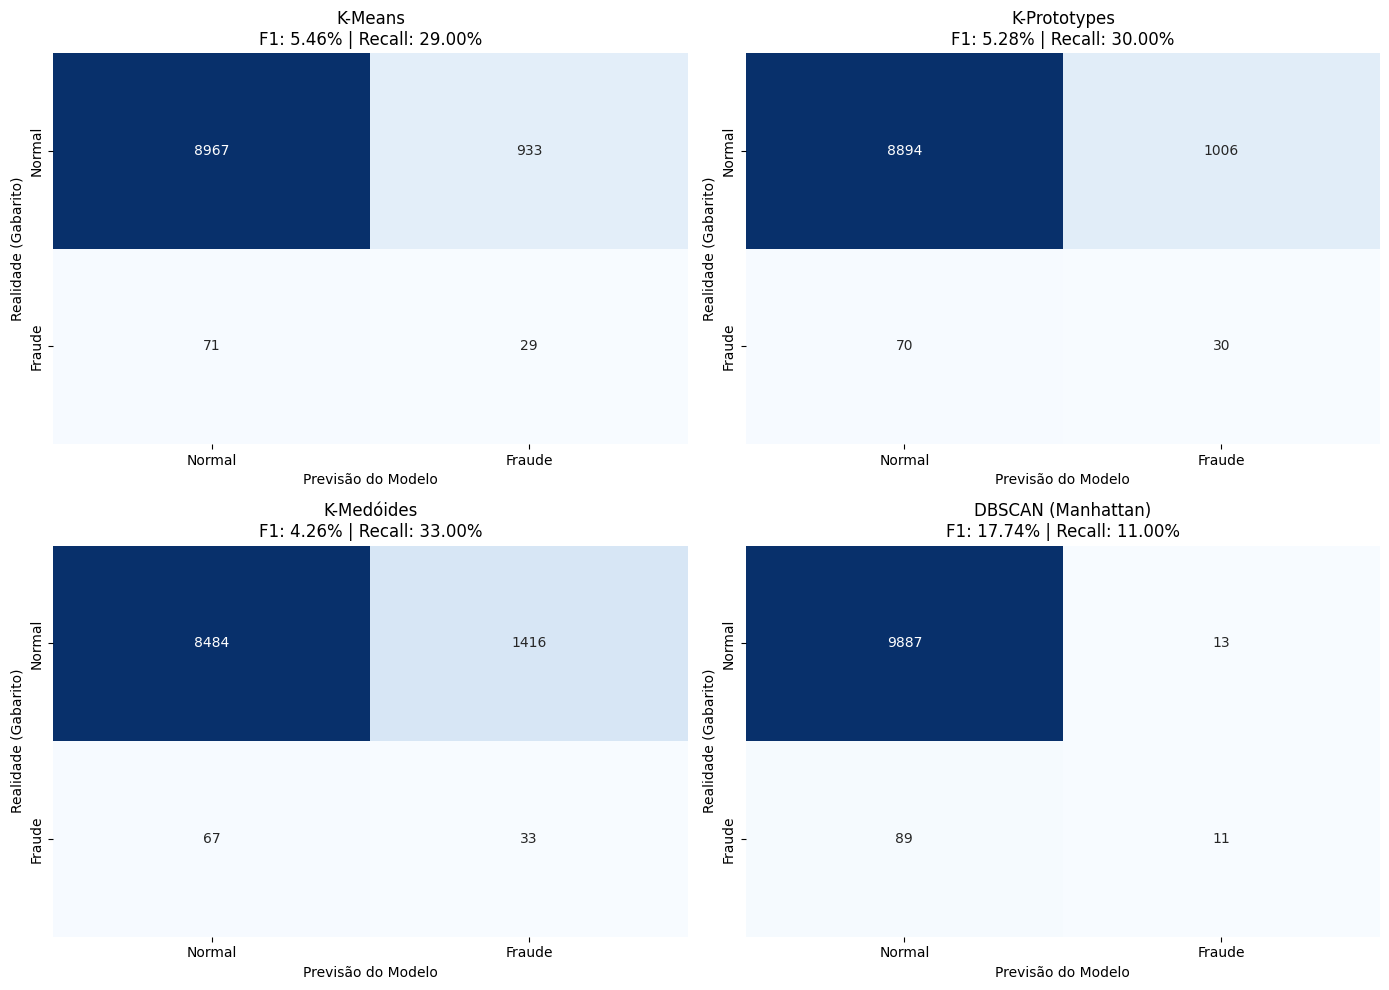

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn_extra.cluster import KMedoids
from kmodes.kprototypes import KPrototypes

df['Cluster_KMeans'] = kmeans_final.predict(X_num) 
df['Cluster_KMedoides'] = kmedoids.predict(X_num)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_num)
df['Cluster_KPrototypes'] = kproto.predict(df_kproto.values, categorical=indices_categoricos)

print("COMPARATIVO FINAL DE DESEMPENHO\n")

# LISTA DOS MODELOS 
colunas_modelos = ['Cluster_KMeans', 'Cluster_KPrototypes', 'Cluster_KMedoides', 'Cluster_DBSCAN']
nomes_modelos = ['K-Means', 'K-Prototypes', 'K-Medóides', 'DBSCAN (Manhattan)']

# DESENHAR OS GRÁFICOS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(colunas_modelos):
    # Tradução para 0 = Normal, 1 = Fraude
    if col == 'Cluster_DBSCAN':
        # Para o DBSCAN, usamos o Ruído (-1)
        previsoes = (df[col] == -1).astype(int)
    else:
        # Para os outros, achamos o grupo que mais concentrou fraudes
        taxa_fraude = df.groupby(col)['Anomalia'].mean()
        cluster_suspeito = taxa_fraude.idxmax()
        previsoes = (df[col] == cluster_suspeito).astype(int)

    # CÁLCULO DAS MÉTRICAS
    gabarito = df['Anomalia']
    acc = accuracy_score(gabarito, previsoes)
    prec = precision_score(gabarito, previsoes, zero_division=0)
    rec = recall_score(gabarito, previsoes)
    f1 = f1_score(gabarito, previsoes)

    print(f"{nomes_modelos[i]}:")
    print(f"Acurácia: {acc*100:.2f}% | Precisão: {prec*100:.2f}% | Recall: {rec*100:.2f}% | F1-Score: {f1*100:.2f}%\n")

    # MATRIZ DE CONFUSÃO
    cm = confusion_matrix(gabarito, previsoes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Fraude'], 
                yticklabels=['Normal', 'Fraude'],
                cbar=False)
    
    axes[i].set_title(f'{nomes_modelos[i]}\nF1: {f1*100:.2f}% | Recall: {rec*100:.2f}%')
    axes[i].set_ylabel('Realidade (Gabarito)')
    axes[i].set_xlabel('Previsão do Modelo')

plt.tight_layout()
plt.show()